In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
# from datasets import load_dataset

In [2]:
df = pd.read_parquet('data/dataset.parquet')
# dataset = load_dataset('parquet', data_files='data/dataset.parquet')

In [4]:
df['Language'].value_counts()

Language
js     13532
cpp     3322
py      3040
c       1477
Name: count, dtype: int64

In [ ]:
def drop_by_language(df, lang: str, count: int):
    indexes = df[df['Language'] == lang].index
    indexes_to_drop = df.loc[indexes].sample(n=count).index
    df.drop(indexes_to_drop, inplace=True)

drop_by_language(df, 'js',  12_500)
drop_by_language(df, 'cpp', 2_300)
drop_by_language(df, 'py',  2_000)
drop_by_language(df, 'c',   400)


In [ ]:
def get_windows(content: str, window_size=100, stride=75):
    lines = content.splitlines()

    snippets = []
    for i in range(0, len(lines) - window_size + 1, stride):
        window = lines[i : i + window_size]
        
        if len("".join(window).strip()) > 50: 
            snippets.append("\n".join(window))
    return snippets

df['Snippets'] = df['Content'].apply(lambda x: get_windows(x))
df_snippets = df.explode('Snippets')
df_snippets = df_snippets.dropna(subset=['Snippets'])
df_final = df_snippets[['Snippets', 'Language']].reset_index(drop=True)
df = df_final
df.rename(columns={'Snippets': 'Content', 'Language': 'Language'}, inplace=True)

In [28]:
df['Language'].value_counts()

Language
c      8528
cpp    5841
js     4356
py     1319
Name: count, dtype: int64

In [7]:
from cleaner import clean

clean(df)

# print(df['Content'].str.len().describe())

# df['Content'] = df['Content'].str[:1000]
df['Length'] = df['Content'].str.len()

df = df[df['Length'] > 10]

print(df['Length'].describe())

count     17996.000000
mean       2764.287008
std        3036.330134
min         128.000000
25%        2007.750000
50%        2544.000000
75%        3180.000000
max      296832.000000
Name: Length, dtype: float64


In [31]:
df.groupby('Language')['Length'].sum()

Language
c      22236937
cpp    18060462
js     14168767
py      4061855
Name: Length, dtype: int64

In [8]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import FeatureUnion
from sklearn.compose import ColumnTransformer

token_pattern = r'(?u)\b\w\w+\b|(?P<punc>[!@#$%^&*()\-+={}\[\]|\\:;"\'<>,.?/])'
word_vec = TfidfVectorizer(
    lowercase=False,
    token_pattern=token_pattern,
    ngram_range=(1, 2),
    max_features=5000
)

char_vec = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 4),
    max_features=5000
)

vectorizer = FeatureUnion([
    ('word', word_vec),
    ('char', char_vec)
])

def extract_meta_features(text_series):
    features = pd.DataFrame()
    features['semicolon_density'] = text_series.str.count(';') / text_series.str.len()
    features['brace_ratio'] = (text_series.str.count('{') + text_series.str.count('}')) / text_series.str.len()
    features['pointer_marker'] = text_series.str.contains(r'\w+\*').astype(int)
    features['python_marker'] = text_series.str.contains(r'def |elif |import ').astype(int)
    return features.fillna(0)

meta_transformer = FunctionTransformer(extract_meta_features)

ct = ColumnTransformer(
    transformers=[
        ('vec', vectorizer, 'Content'),
        ('extras', meta_transformer, 'Content')
    ]
)

tfidf_matrix = ct.fit_transform(df)

# tfidf = pd.DataFrame(
#     tfidf_matrix.toarray(),
#     columns=ct.get_feature_names_out()
# )

In [9]:
from sklearn.model_selection import train_test_split

X = tfidf_matrix
y = df['Language']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def get_score(n_estimators, X, y):
    model = RandomForestClassifier(n_estimators=n_estimators)

    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring='accuracy'
    )
    return scores.mean()

In [30]:
for n in [24, 64, 128, 256]:
    print(n, get_score(n, X_train, y_train))

24 -0.981187103576105
64 -0.9845071164997364
128 -0.9859831312598841
256 -0.9857989695104324


In [11]:
model = RandomForestClassifier(
    n_estimators=256,
    class_weight='balanced',
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",256
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

preds = model.predict(X_test)
loss = accuracy_score(y_test, preds)
print(loss)

# 0.9880404783808647 loss (with comments, balanced, max 1000 chars)
# 0.988950276243094  loss (no   comments, balanced, max 1000 chars)
# 0.9832876028934896 loss (snippetized (1000 per lang), no comments, unbalanced)

0.9830555555555556


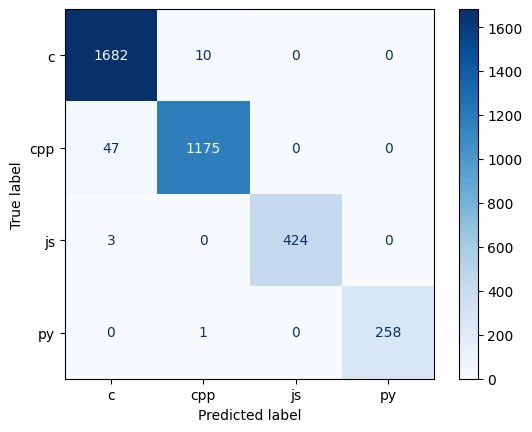

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.show()

In [18]:
my_test_file = ""
with open('test_file.txt', 'r') as file:
    my_test_file = file.read()

my_test_df = pd.DataFrame({'Content': [my_test_file]})
my_test_matrix = ct.transform(my_test_df)

print(my_test_file)
model.predict(my_test_matrix)

for i in range(1..10):
    print(i)


array(['py'], dtype=object)